## Implementing MergeDNA
### Demo Notebook
#### Shruti Shikhare

End-to-end walkthrough of the MergeDNA model:
- DNA encoding and embedding
- Step-by-step forward pass through each component
- Source matrix S visualisation — which bases merged into which tokens
- All 3 pre-training passes + novel combined loss
- Integrating inference helpers
- Compression ratio distribution

In [1]:
import sys, os
# Make sure the repo root is on the path
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
# import matplotlib.ticker as ticker

print(f"PyTorch {torch.__version__}")
print(f"device: {'cuda' if torch.cuda.is_available() else 'cpu'}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

PyTorch 2.10.0
device: cpu


#### DNA encoding

In [2]:
from src.model.embedding import encode_batch, encode_sequence, VOCAB, VOCAB_SIZE

seqs = [
    "ATCGATCGATCG",
    "GGCCTTAAGGCC",
    "ACGTNNACGT",
]

# this function encodes a batch of sequences into token IDs, X, along with their lengths, L
ids, lengths = encode_batch(seqs)

print("Token IDs shape:", ids.shape)   # [3, 12]
print("Lengths:        ", lengths.tolist())
print()
print("VOCAB mapping:", VOCAB)
print()
for seq, row in zip(seqs, ids):
    print(f"  {seq:20s}  ->  {row.tolist()}")

Token IDs shape: torch.Size([3, 12])
Lengths:         [12, 12, 10]

VOCAB mapping: {'A': 0, 'C': 1, 'T': 2, 'G': 3, 'N': 4}

  ATCGATCGATCG          ->  [0, 2, 1, 3, 0, 2, 1, 3, 0, 2, 1, 3]
  GGCCTTAAGGCC          ->  [3, 3, 1, 1, 2, 2, 0, 0, 3, 3, 1, 1]
  ACGTNNACGT            ->  [0, 1, 3, 2, 4, 4, 0, 1, 3, 2, 0, 0]


##### Create a test model
- Model defaults found in "MergeDNAConfig()" (d_model=1024, ~386M params) -> too computationally intensive.
- For the demo we shrink every dimension to run instantly on CPU.

In [3]:
from src.model.mergedna import MergeDNA, MergeDNAConfig

# reduced config for demo down to 128 dimensions, less heads
cfg = MergeDNAConfig(
    d_model=128,
    n_heads=4,
    local_enc_layers=4,
    latent_enc_layers=4,    # 4 << 20 for speed
    latent_dec_layers=2,    # 2 < 4 for speed
    local_dec_layers=2,
    window_size=16,
    d_group=16,
    use_flash=False,         # False for demo
    dropout=0.0,
)

model = MergeDNA(cfg).to(device)
model.train()

total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")
print(f"Config: d_model={cfg.d_model}, n_heads={cfg.n_heads}")
print(f"        local_enc_layers={cfg.local_enc_layers}, latent_enc_layers={cfg.latent_enc_layers}")

Total parameters: 3,165,024
Config: d_model=128, n_heads=4
        local_enc_layers=4, latent_enc_layers=4


#### Forward pass

In [ ]:
# embedding model

from src.model.embedding import encode_batch
# torch.manual_seed(42)

dna_sequences = [
    # 1. Putative protein-coding sequence (starts with ATG, plausible ORF)
    "ATGGCCATTGTAATGGGCCGCTGAAAGGGTGCCCGATAGCGTACCGGTTTACGATGCTGACTGACCGTTACGATGACCTGATCGTAGCTAG",
    
    # 2. Coding-like sequence with a stop codon (TAA at end)
    "ATGCGTACGTTGACCTGATCGGATCGTACGATCGTAGCTAGCTAGGCTAGCTAGGATCCGATGCTAGCTAGCTAACTGATCGTAGCTAA",
    
    # 3. Promoter-like region (contains TATA box motif: TATAAA)
    "TATAAAGGCGCGCCATGGCTAGCTAGCGTACGATCGATCGGCTAGCTAGGATCGATCGTAGCTAGCTAGCGTACGATCGATCGTAGCTA",
    
    # 4. GC-rich coding/regulatory hybrid (high GC content typical of some genomes)
    "ATGCGCGGCGGCCGCGTACGCGGATCGCGGCTAGCGGCTAGCGCGATCGCGGCTAGCGATCGCGGCTAGCTAGCGCGATCGCGGCTAGC",
    
    # 5. Coding-like sequence with multiple codons and internal motifs
    "ATGACCATGATTACGCCAAGCTTGGTACCGAGCTCGGTACCATGGCCATTGTAATGGGCCGCTGAAAGGGTGCCCGATAGCTAGCTGA",
    
    # 6. Random noncoding sequence (no clear ORF)
    "GCTTACGATCGTAGCTAGCTAGGCTAGCTAGCATCGATCGTAGCTAGCTGATCGTAGCTAGCTAGCTAGCATCGATCGTAGCTAGCTA",
    
    # 7. AT-rich noncoding region (low complexity, unlikely to encode protein)
    "ATATTTATATAAATTTATATATTTAAATATATTTATATAAATTTATATATTTAAATATATTTATATAAATTTATATATTTAAATATA",
    
    # 8. Mixed random noncoding sequence
    "CGTAGCTAGGATCGATCGTAGCTAGCTAGCTAGGATCGATCGTAGCTAGCTAGCATCGATCGTAGCTAGCTAGGATCGATCGTAGCTA",
    
    # 9. Repetitive noncoding motif (alternating GC/AT pattern)
    "GCGCGATATATCGCGCGATATATCGCGCGATATATCGCGCGATATATCGCGCGATATATCGCGCGATATATCGCGCGATATATCGCGC",
    
    # 10. Low-complexity noncoding repeat-like sequence
    "TTGACGATCGTTAGCTAGTTGACGATCGTTAGCTAGTTGACGATCGTTAGCTAGTTGACGATCGTTAGCTAGTTGACGATCGTTAGCTA"
]
B, N = 10, 91
# BASES = list("ACGT")


token_ids, _ = encode_batch(dna_sequences)
token_ids = token_ids.to(device)

x = model.embedding(token_ids)   
x.shape # = [B, N, D]

torch.Size([10, 91, 128])

### Local encoder

In [5]:
from src.model.tome.source_matrix import token_sizes_from_source

z_L, S = model.local_encoder(x)

print(f"Input  x  : {x.shape}")
print(f"Output z_L: {z_L.shape}   (L = {z_L.shape[1]}, target ~N/2 = {N//2})")
print(f"Source S  : {S.shape}     (maps L merged tokens -> N original bases)")
print()

# Token sizes = how many bases each merged token represents
tok_sizes = token_sizes_from_source(S)   # [B, L]
print(f"Token sizes (batch 0): {tok_sizes[0].int().tolist()}")
print(f"  sum = {tok_sizes[0].sum().int().item()}  (should equal N={N})")
print(f"  min={tok_sizes[0].min().int().item()}, max={tok_sizes[0].max().int().item()}, "
      f"mean={tok_sizes[0].mean().item():.2f}")

Input  x  : torch.Size([10, 91, 128])
Output z_L: torch.Size([10, 47, 128])   (L = 47, target ~N/2 = 45)
Source S  : torch.Size([10, 47, 91])     (maps L merged tokens -> N original bases)

Token sizes (batch 0): [2, 2, 2, 1, 1, 1, 1, 1, 1, 2, 2, 2, 1, 1, 2, 2, 1, 2, 1, 2, 1, 1, 2, 2, 1, 1, 2, 2, 1, 1, 2, 2, 1, 1, 1, 1, 1, 4, 1, 2, 2, 1, 1, 1, 2, 0, 0]
  sum = 67  (should equal N=91)
  min=0, max=4, mean=1.43


#### Latent encoder & latent decoder

In [6]:
# Latent Encoder (wihtout any ToMe in Pass 1)
token_sizes = token_sizes_from_source(S)
z_L_prime = model.latent_encoder(z_L, token_sizes=token_sizes)
print(f"Latent Encoder output z_L': {z_L_prime.shape}")

# Latent Decoder
z_hat_L = model.latent_decoder(z_L_prime)
print(f"Latent Decoder output z_hat_L: {z_hat_L.shape}")

Latent Encoder output z_L': torch.Size([10, 47, 128])
Latent Decoder output z_hat_L: torch.Size([10, 47, 128])


#### Local decoder

In [7]:
from src.model.tome.source_matrix import unmerge_with_source

# unmerge: L tokens -> N base representations
z_bar_N = unmerge_with_source(z_hat_L, S)
print(f"After unmerge z_bar_N: {z_bar_N.shape}  (back to N={N} bases)")

# Local Decoder
logits = model.local_decoder(z_bar_N)
print(f"Local Decoder outputs : {logits.shape}  (B={B}, N={N}, vocab={VOCAB_SIZE})")

# get prediction accuracy
preds = logits.argmax(dim=-1)   # [B, N]
acc = (preds == token_ids).float().mean().item()
print(f"\nReconstruction accuracy (untrained): {acc*100:.1f}%  (random baseline: 25%)")

After unmerge z_bar_N: torch.Size([10, 91, 128])  (back to N=91 bases)
Local Decoder outputs : torch.Size([10, 91, 5])  (B=10, N=91, vocab=5)

Reconstruction accuracy (untrained): 7.6%  (random baseline: 25%)


#### Source matrix, S[b, i, j] = 1

/var/folders/sh/_3tc70kd6_q6_1q_wpyhq7dh0000gq/T/ipykernel_6443/1348562197.py:15: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


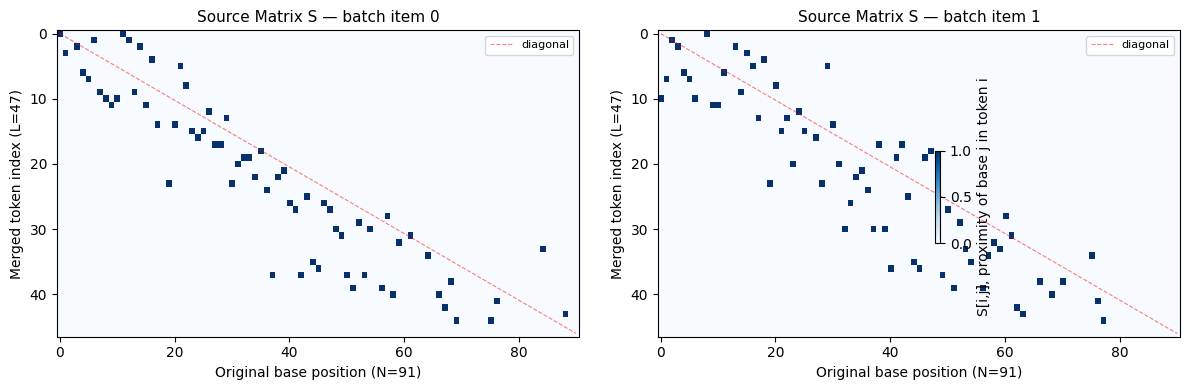

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, b in zip(axes, [0, 1]):
    s = S[b].detach().cpu().numpy()   # [L, N]
    im = ax.imshow(s, aspect="auto", cmap="Blues", vmin=0, vmax=1,
                   interpolation="nearest")
    ax.set_xlabel(f"Original base position (N={N})", fontsize=10)
    ax.set_ylabel(f"Merged token index (L={s.shape[0]})", fontsize=10)
    ax.set_title(f"Source Matrix S — batch item {b}", fontsize=11)

    ax.plot([0, N-1], [0, s.shape[0]-1], "r--", lw=0.8, alpha=0.5, label="diagonal") # trend line for perfect mapping
    ax.legend(fontsize=8)

fig.colorbar(im, ax=axes, label="S[i,j], proximity of base j in token i", shrink=0.3)
plt.tight_layout()
plt.show()

# w can see the distribution is dispersed around the trend line which is expected since the model is untrained,
# but there is a clear diagonal structure showing that tokens are mostly merging nearby bases together

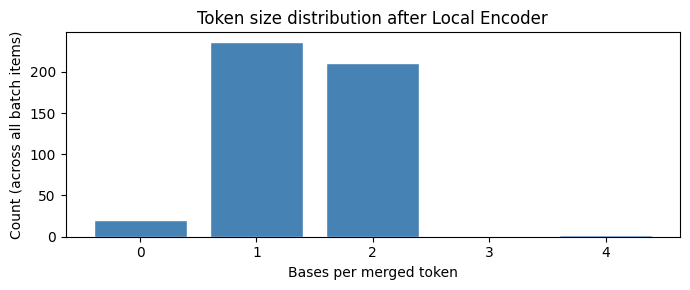

In [9]:
### token size histogram
# how many bases each merged token represents.

all_sizes = tok_sizes.detach().cpu().int().numpy().flatten()

fig, ax = plt.subplots(figsize=(7, 3))
unique, counts = np.unique(all_sizes, return_counts=True)
ax.bar(unique, counts, color="steelblue", edgecolor="white")
ax.set_xlabel("Bases per merged token")
ax.set_ylabel("Count (across all batch items)")
ax.set_title("Token size distribution after Local Encoder")
plt.tight_layout()
plt.show()

#### Latent encoder with Global ToMe (Pass 2)

In [10]:
# running latent encoder with global ToMe
with torch.no_grad():
    x_frozen = model.embedding(token_ids)
    z_L_frozen, S_frozen = model.local_encoder(x_frozen)

token_sizes_frozen = token_sizes_from_source(S_frozen)
z_K, S_prime = model.latent_encoder(
    z_L_frozen.detach(),
    token_sizes=token_sizes_frozen,
    use_tome=True,
)

L = z_L_frozen.shape[1]
K = z_K.shape[1]
print(f"Local Encoder output  Z_L  : {z_L_frozen.shape}   (L={L})")
print(f"Latent Encoder output Z_K  : {z_K.shape}   (K={K}, ~L/2={L//2})")
print(f"Latent source matrix  S'   : {S_prime.shape}   (maps K latent tokens -> L local tokens)")

Local Encoder output  Z_L  : torch.Size([10, 46, 128])   (L=46)
Latent Encoder output Z_K  : torch.Size([10, 23, 128])   (K=23, ~L/2=23)
Latent source matrix  S'   : torch.Size([10, 23, 46])   (maps K latent tokens -> L local tokens)


In [11]:
from src.model.tome.global_tome import compute_importance_mask, expand_token_mask_to_bases

# AMTM masking probabilities derived from S' matrix
mask_token_idx = compute_importance_mask(S_prime, L=L, K=K)   # [B, K]
M_N = expand_token_mask_to_bases(mask_token_idx, S_frozen)     # [B, N]

print(f"Masked token indices shape : {mask_token_idx.shape}")
print(f"Base-level mask M_N shape  : {M_N.shape}")
print(f"Fraction of bases masked   : {M_N.float().mean().item()*100:.1f}%")

# showing which bases are masked for the first sequence
mask0 = M_N[0].cpu().numpy().astype(int)
print(f"\nMask (batch item 0, 1=masked):\n{mask0}")

Masked token indices shape : torch.Size([10, 23])
Base-level mask M_N shape  : torch.Size([10, 91])
Fraction of bases masked   : 37.7%

Mask (batch item 0, 1=masked):
[1 0 0 0 0 1 1 1 0 1 0 1 1 0 0 1 0 0 0 0 1 0 0 1 1 1 1 0 0 0 0 1 0 0 1 1 0
 1 1 0 1 1 0 1 0 1 1 1 1 1 1 1 1 1 1 0 0 0 0 1 0 1 1 0 0 0 0 0 0 0 0 1 0 0
 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


#### Pre-training
Runs all 3 passes: 
1. MTR — reconstruct from merged tokens
2. Latent MTR — reconstruct after global ToMe
3. AMTM — predict importance-weighted masked bases

In [12]:
model.train()
losses = model.pretrain_step(token_ids)

print("=== Pre-training losses (untrained model) ===")
for k, v in losses.items():
    print(f"  {k:<20s}: {v.item():.4f}")
print()
print(f"  Expected random CE loss: {-1 * (1/VOCAB_SIZE) * VOCAB_SIZE * np.log(1/VOCAB_SIZE):.4f}  "
      f"(= ln({VOCAB_SIZE}) = {np.log(VOCAB_SIZE):.4f})")

=== Pre-training losses (untrained model) ===
  loss                : 4.0008
  loss_mtr            : 1.8601
  loss_latent_mtr     : 1.8324
  loss_amtm           : 1.6826

  Expected random CE loss: 1.6094  (= ln(5) = 1.6094)


##### mini training loop
need to confirm if loss reduces

In [13]:
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

history = {"total": [], "mtr": [], "latent_mtr": [], "amtm": []}

model.train()
for step in range(30):
    optimizer.zero_grad()
    out = model.pretrain_step(token_ids)
    out["loss"].backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()

    history["total"].append(out["loss"].item())
    history["mtr"].append(out["loss_mtr"].item())
    history["latent_mtr"].append(out["loss_latent_mtr"].item())
    history["amtm"].append(out["loss_amtm"].item())

    if (step + 1) % 10 == 0:
        print(f"step {step+1:3d}  total={history['total'][-1]:.4f}  "
              f"mtr={history['mtr'][-1]:.4f}  "
              f"latent_mtr={history['latent_mtr'][-1]:.4f}  "
              f"amtm={history['amtm'][-1]:.4f}")

step  10  total=1.9510  mtr=0.3823  latent_mtr=0.5272  amtm=1.4368
step  20  total=1.8325  mtr=0.4076  latent_mtr=0.4779  amtm=1.3054
step  30  total=1.7321  mtr=0.3642  latent_mtr=0.4798  amtm=1.2479


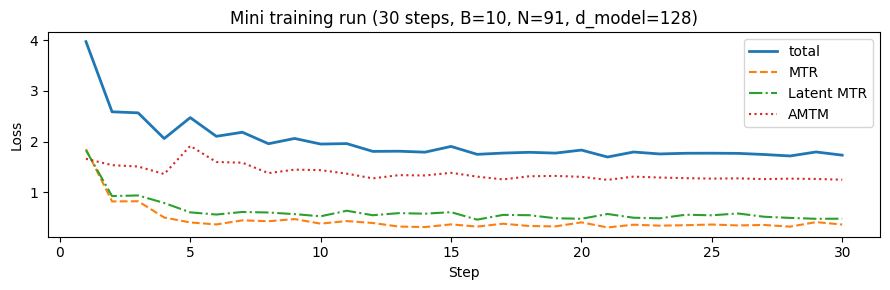

In [14]:
fig, ax = plt.subplots(figsize=(9, 3))
steps = range(1, len(history["total"]) + 1)
ax.plot(steps, history["total"],      label="total",       lw=2)
ax.plot(steps, history["mtr"],        label="MTR",         lw=1.5, ls="--")
ax.plot(steps, history["latent_mtr"], label="Latent MTR",  lw=1.5, ls="-.")
ax.plot(steps, history["amtm"],       label="AMTM",        lw=1.5, ls=":")
ax.set_xlabel("Step")
ax.set_ylabel("Loss")
ax.set_title(f"Mini training run (30 steps, B={B}, N={N}, d_model=128)")
ax.legend()
plt.tight_layout()
plt.show()

#### inference

Three inference helpers are provided and used during model evaluation:

1. encode(ids)
2. encode_pooled(ids, mode)
3. reconstruct(ids)

In [15]:
model.eval()

# encode: per-token latent embeddings
z_tokens = model.encode(token_ids)
print(f"encode()        -> {z_tokens.shape}   (B={B}, L≈{N//2}, D={cfg.d_model})")

# encode_pooled
for mode in ("mean", "max", "cls"):
    z_seq = model.encode_pooled(token_ids, mode=mode)
    print(f"encode_pooled(mode={mode!r:6s}) -> {z_seq.shape}  (B={B}, D={cfg.d_model})")

# reconstruct
recon_outputs = model.reconstruct(token_ids)   # [B, N, V]
preds = recon_outputs.argmax(dim=-1)           # [B, N]
acc = (preds == token_ids).float().mean().item()
print(f"\nreconstruct()   -> {recon_outputs.shape}")
print(f"Reconstruction accuracy (after 30 steps): {acc*100:.1f}%")

encode()        -> torch.Size([10, 46, 128])   (B=10, L≈45, D=128)
encode_pooled(mode='mean') -> torch.Size([10, 128])  (B=10, D=128)
encode_pooled(mode='max' ) -> torch.Size([10, 128])  (B=10, D=128)
encode_pooled(mode='cls' ) -> torch.Size([10, 128])  (B=10, D=128)

reconstruct()   -> torch.Size([10, 91, 5])
Reconstruction accuracy (after 30 steps): 87.7%


#### Copilot suggestion: Cosine similarity between sequence embeddings

After encoding, sequences that are more similar should have higher cosine similarity

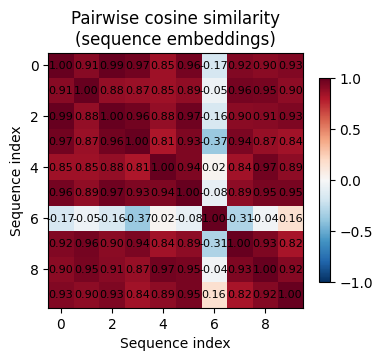

In [16]:
z_pooled = model.encode_pooled(token_ids, mode="mean")   # [B, D]
z_norm   = F.normalize(z_pooled, dim=-1)
sim_matrix = (z_norm @ z_norm.T).cpu().detach().numpy()

fig, ax = plt.subplots(figsize=(4, 3.5))
im = ax.imshow(sim_matrix, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_title("Pairwise cosine similarity\n(sequence embeddings)")
ax.set_xlabel("Sequence index")
ax.set_ylabel("Sequence index")
for i in range(B):
    for j in range(B):
        ax.text(j, i, f"{sim_matrix[i,j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

#### Copilot suggestion: Compression Ratio Distribution

During training the Local Encoder samples a Gaussian compression ratio
`L/N ~ N(0.5, 0.05)`, clamped to [0.4, 0.6].
During eval it deterministically uses `L = round(N * 0.5)`.

The cell below shows the distribution over many training calls.

Compression ratio  L/N:  mean=0.494  std=0.049
Range: [0.396, 0.593]  (paper clamps to [0.4, 0.6])


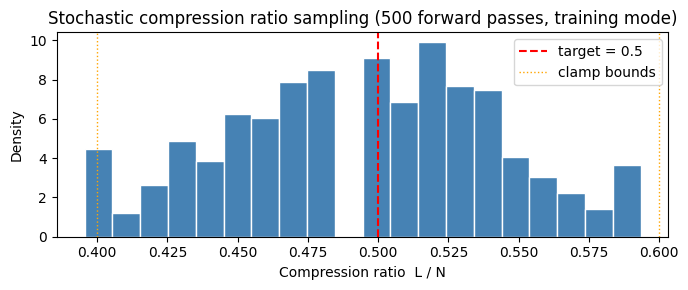

In [17]:
model.train()   # sampling only active in training mode

ratios = []
for _ in range(500):
    with torch.no_grad():
        xb = model.embedding(token_ids)
        zb, Sb = model.local_encoder(xb)
    ratios.append(zb.shape[1] / N)

ratios = np.array(ratios)
print(f"Compression ratio  L/N:  mean={ratios.mean():.3f}  std={ratios.std():.3f}")
print(f"Range: [{ratios.min():.3f}, {ratios.max():.3f}]  (paper clamps to [0.4, 0.6])")

fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(ratios, bins=20, color="steelblue", edgecolor="white", density=True)
ax.axvline(0.5,  color="red",   lw=1.5, ls="--",  label="target = 0.5")
ax.axvline(0.4,  color="orange",lw=1,   ls=":",   label="clamp bounds")
ax.axvline(0.6,  color="orange",lw=1,   ls=":")
ax.set_xlabel("Compression ratio  L / N")
ax.set_ylabel("Density")
ax.set_title("Stochastic compression ratio sampling (500 forward passes, training mode)")
ax.legend()
plt.tight_layout()
plt.show()